In [1]:
from pathlib import Path
import pandas as pd
from formulation.common import ProblemDataReal
from formulation.formulation_3.problem3_definition import Formulation3
from formulation.formulation_3.formulation3_gurobipy import build_model_from_definition, solve_problem
from formulation.formulation_3.solution import Formulation3ModelBundle
from experiments.all_gurobi_julia import _build_run_scopes
import networkx as nx
import matplotlib.pyplot as plt
from copy import deepcopy
from itertools import product
from haversine import haversine
import numpy as np
import math

In [2]:
cache_path = Path("formulation/cache/framingham_problem_data.pkl")
problem_data = ProblemDataReal.load_path(cache_path)
scope = _build_run_scopes(problem_data, per_school=True, per_school_type=False)

In [3]:
i, j = 0, 28

f = Formulation3(problem_data=scope[0].problem_data, rounds=1)
b_old = deepcopy(f.B)
m_old = deepcopy(f.M)

all_stops = sorted(
    {m.stop for m in m_old},
    key=lambda stop: (
        haversine(
            (f.S[0].geographic_location.y, f.S[0].geographic_location.x),
            (stop.geographic_location.y, stop.geographic_location.x),
        ),
        stop.node_id,
        stop.name,
    ),
)

selected_stops = set(all_stops[i:j])

f.B = b_old[:1]
f.M = [m for m in m_old if m.stop in selected_stops]

print(f"Selected stops: {len(selected_stops)}")
print(f"Total students to be served: {len(f.M)}")

p: Formulation3ModelBundle = build_model_from_definition(f)

Selected stops: 28
Total students to be served: 64
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2440707
Academic license 2440707 - for non-commercial use only - registered to ri___@mit.edu
Set parameter OutputFlag to value 1
Set parameter LogToConsole to value 1
Set parameter LogFile to value "gurobi-2026-04-17 22:19:14.343287.log"


2026-04-17 22:19:14.343 | INFO     | formulation.formulation_3.formulation3_gurobipy:build_model_from_definition:160 - model initialized :3
2026-04-17 22:19:14.343 | INFO     | formulation.formulation_3.formulation3_gurobipy:build_model_from_definition:163 - z_b vars added
2026-04-17 22:19:14.344 | INFO     | formulation.formulation_3.formulation3_gurobipy:build_model_from_definition:165 - z_bq vars added
2026-04-17 22:19:14.344 | INFO     | formulation.formulation_3.formulation3_gurobipy:build_model_from_definition:167 - y_bqtau vars added
2026-04-17 22:19:14.525 | INFO     | formulation.formulation_3.formulation3_gurobipy:build_model_from_definition:169 - v_bqi vars added
2026-04-17 22:19:14.526 | INFO     | formulation.formulation_3.formulation3_gurobipy:build_model_from_definition:171 - a_mbq vars added
2026-04-17 22:19:14.526 | INFO     | formulation.formulation_3.formulation3_gurobipy:build_model_from_definition:181 - T_bqi vars added
2026-04-17 22:19:14.527 | INFO     | formulat

In [3]:
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import eigsh
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def choose_k_from_embedding(evecs, evals, k_max=20, random_state=0):
    m = min(k_max + 1, evecs.shape[1])

    # eigengap suggestion: skip the first trivial eigenvalue
    gaps = np.diff(evals[:m])
    k_gap = int(np.argmax(gaps[1:]) + 2) if m > 2 else 2

    best = {"k": None, "score": -np.inf, "labels": None}

    for k in range(2, min(k_max, m - 1) + 1):
        X = evecs[:, 1 : k + 1]   # skip trivial eigenvector
        X = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)

        labels = KMeans(n_clusters=k, n_init=20, random_state=random_state).fit_predict(X)

        if len(np.unique(labels)) < 2:
            continue

        score = silhouette_score(X, labels, metric="euclidean")
        if score > best["score"]:
            best = {"k": k, "score": score, "labels": labels}

    if best["labels"] is None:
        k = max(2, min(k_gap, m - 1))
        X = evecs[:, 1 : k + 1]
        X = X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)
        labels = KMeans(n_clusters=k, n_init=20, random_state=random_state).fit_predict(X)
        best = {"k": k, "score": np.nan, "labels": labels}

    return best, k_gap

def multidigraph_to_affinity(
    G: nx.MultiDiGraph,
    distance_attr: str = "length",
    sigma: float | None = None,
    parallel_mode: str = "min",  # "min" or "sum"
):
    nodes = list(G.nodes())
    idx = {u: i for i, u in enumerate(nodes)}

    distances = [
        float(data[distance_attr])
        for _, _, _, data in G.edges(keys=True, data=True)
        if distance_attr in data
    ]
    if not distances:
        raise ValueError(f"No edge attribute '{distance_attr}' found.")
    if sigma is None:
        sigma = float(np.median(distances))

    agg: dict[tuple[object, object], float] = {}
    for u, v, _, data in G.edges(keys=True, data=True):
        d = float(data[distance_attr])
        a = np.exp(-d / max(sigma, 1e-12))  # distance -> similarity

        if parallel_mode == "min":
            # keep the strongest affinity, equivalent to keeping the shortest edge
            agg[(u, v)] = max(agg.get((u, v), 0.0), a)
        elif parallel_mode == "sum":
            agg[(u, v)] = agg.get((u, v), 0.0) + a
        else:
            raise ValueError("parallel_mode must be 'min' or 'sum'")

    rows, cols, vals = zip(*[(idx[u], idx[v], w) for (u, v), w in agg.items()])
    A = csr_matrix((vals, (rows, cols)), shape=(len(nodes), len(nodes)), dtype=float)
    return A, nodes


def row_stochastic(A, eps=1e-12):
    out = np.asarray(A.sum(axis=1)).ravel()
    return diags(1.0 / np.maximum(out, eps)) @ A


def directed_spectral_clustering(
    G: nx.MultiDiGraph,
    k: int | None = None,
    distance_attr: str = "length",
    sigma: float | None = None,
    teleport: float = 0.02,
    random_state: int = 0,
    k_max: int = 20,
):
    wccs = list(nx.weakly_connected_components(G))
    H = G.subgraph(max(wccs, key=len)).copy()

    A, nodes = multidigraph_to_affinity(H, distance_attr=distance_attr, sigma=sigma)
    P = row_stochastic(A)

    n = P.shape[0]
    P = (1.0 - teleport) * P.toarray() + teleport * np.full((n, n), 1.0 / n)

    pi = np.full(n, 1.0 / n)
    for _ in range(20000):
        new_pi = pi @ P
        if np.linalg.norm(new_pi - pi, 1) < 1e-12:
            break
        pi = new_pi
    pi = np.maximum(pi, 1e-15)
    pi /= pi.sum()

    Pi_half = np.diag(np.sqrt(pi))
    Pi_mhalf = np.diag(1.0 / np.sqrt(pi))
    S = 0.5 * (Pi_half @ P @ Pi_mhalf + Pi_mhalf @ P.T @ Pi_half)
    L = np.eye(n) - S

    m = min(k_max + 1, n - 1)
    evals, evecs = eigsh(csr_matrix(L), k=m, which="SM")
    order = np.argsort(evals)
    evals = evals[order]
    evecs = evecs[:, order]

    if k is None:
        best, k_gap = choose_k_from_embedding(
            evecs,
            evals,
            k_max=k_max,
            random_state=random_state,
        )
        return {
            "nodes": nodes,
            "labels": best["labels"],
            "k": best["k"],
            "silhouette": best["score"],
            "k_eigengap": k_gap,
            "eigenvalues": evals,
        }

    X = evecs[:, 1 : k + 1]
    X /= np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-12)

    labels = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=random_state,
    ).fit_predict(X)

    return {
        "nodes": nodes,
        "labels": labels,
        "k": k,
        "silhouette": None,
        "k_eigengap": None,
        "eigenvalues": evals,
    }


def keep_n_nearest_edges(
    G: nx.MultiDiGraph,
    n: int,
    distance_attr: str = "length",
) -> nx.MultiDiGraph:
    H = nx.MultiDiGraph()
    H.graph.update(G.graph)

    # keep all nodes and their attributes
    H.add_nodes_from(G.nodes(data=True))

    for u in G.nodes():
        outgoing = []
        for _, v, k, data in G.out_edges(u, keys=True, data=True):
            if distance_attr not in data or u == v:
                continue
            outgoing.append((float(data[distance_attr]), u, v, k, data))

        outgoing.sort(key=lambda x: x[0])

        for _, u, v, k, data in outgoing[:n]:
            H.add_edge(u, v, key=k, **data)

    return H


In [22]:
scopes = _build_run_scopes(problem_data, per_school=True, per_school_type=False)
results = {}
for scope in scopes:
    scoped_problem_data = scope.problem_data
    G = scoped_problem_data.service_graph.copy()

    for place in scoped_problem_data.all_nodes:
        G.nodes[place.node_id]["x"] = place.geographic_location.x
        G.nodes[place.node_id]["y"] = place.geographic_location.y

    n = G.number_of_nodes()
    m = G.number_of_edges()
    print("nodes:", n, "edges:", m, "density approx:", m / max(n * (n - 1), 1))

    stop_ids = {p.node_id for p in scoped_problem_data.stops}
    school_ids = {s.node_id for s in scoped_problem_data.schools}
    depot_ids = {d.node_id for d in scoped_problem_data.depots}
    print("stops:", len(stop_ids), "schools:", len(school_ids), "depots:", len(depot_ids))

    stop_ids = {p.node_id for p in problem_data.stops}
    G_stops = G.subgraph(stop_ids).copy()
    G_local = keep_n_nearest_edges(G_stops, n=10, distance_attr="length")

    res = directed_spectral_clustering(G_local, k_max=20, distance_attr="length")
    node_to_cluster = dict(zip(res["nodes"], res["labels"]))
    print(f"Clusters: {res['k']}")
    results[scope.label_suffix] = {
        "num_clusters": res["k"],
        "silhouette": res["silhouette"],
        "k_eigengap": res["k_eigengap"],
        "eigenvalues": res["eigenvalues"],
        "graph": G_local,
    }

# Have 
G = problem_data.service_graph.copy()
complete_G_local = keep_n_nearest_edges(G.subgraph(stop_ids).copy(), n=10, distance_attr="length")

nodes: 226 edges: 50688 density approx: 0.9968141592920354
stops: 224 schools: 1 depots: 1
Clusters: 16
nodes: 187 edges: 34648 density approx: 0.9961474325800701
stops: 185 schools: 1 depots: 1
Clusters: 15
nodes: 216 edges: 46285 density approx: 0.9966623600344531
stops: 214 schools: 1 depots: 1
Clusters: 3
nodes: 174 edges: 29970 density approx: 0.9956149093083516
stops: 172 schools: 1 depots: 1
Clusters: 5
nodes: 236 edges: 55294 density approx: 0.9970068517850703
stops: 235 schools: 1 depots: 1
Clusters: 9
nodes: 407 edges: 164938 density approx: 0.998160274022343
stops: 405 schools: 1 depots: 1
Clusters: 9
nodes: 216 edges: 46288 density approx: 0.9967269595176572
stops: 214 schools: 1 depots: 1
Clusters: 5
nodes: 116 edges: 13263 density approx: 0.9942278860569715
stops: 115 schools: 1 depots: 1
Clusters: 2
nodes: 193 edges: 36904 density approx: 0.9958981001727115
stops: 191 schools: 1 depots: 1
Clusters: 7
nodes: 190 edges: 35773 density approx: 0.9961849067112225
stops: 188 s

In [19]:
print(len(problem_data.stops))
print(len(problem_data.service_graph.nodes()))
# TODO figure out why we have less stop nodes than stops in the problem data
# TODO seems like we snapped the stops to the closest OSM road network node, which may have caused some stops to be snapped to the same node, resulting in fewer unique nodes in the service graph than the number of stops in the problem data.

628
494


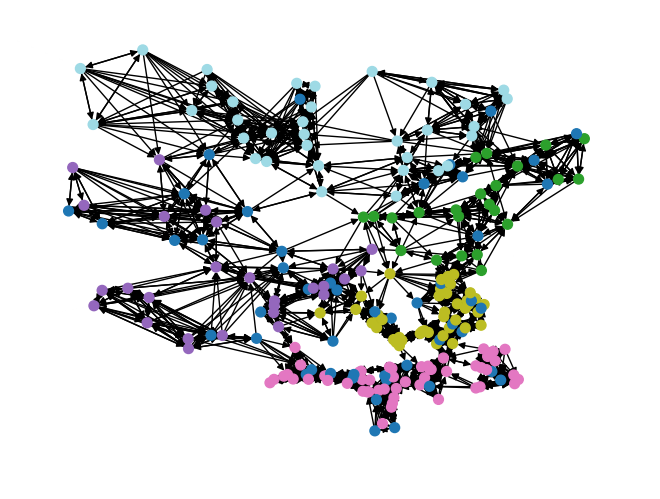

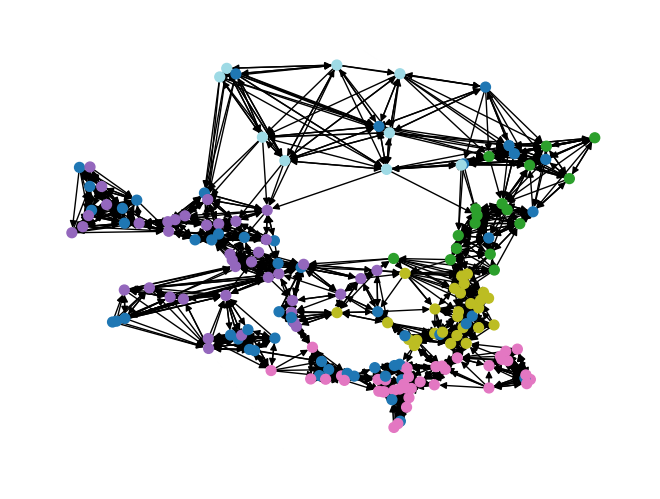

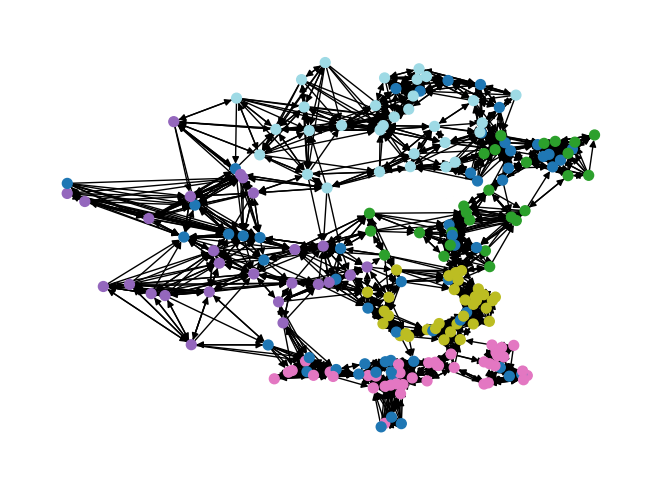

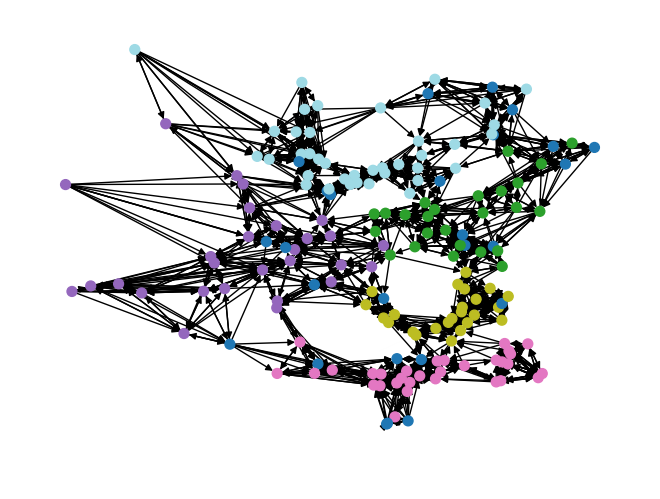

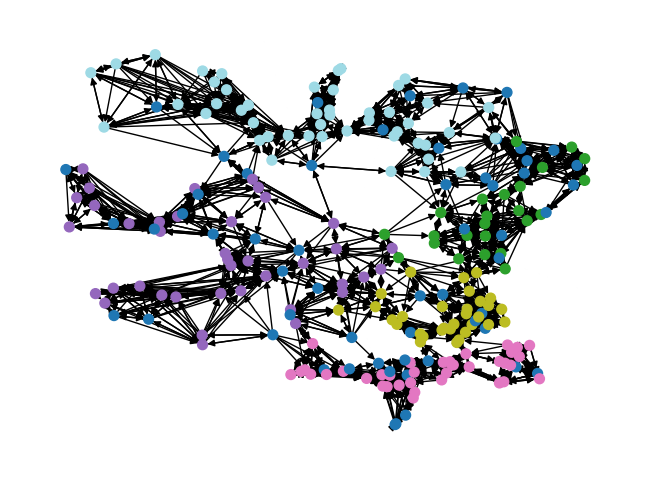

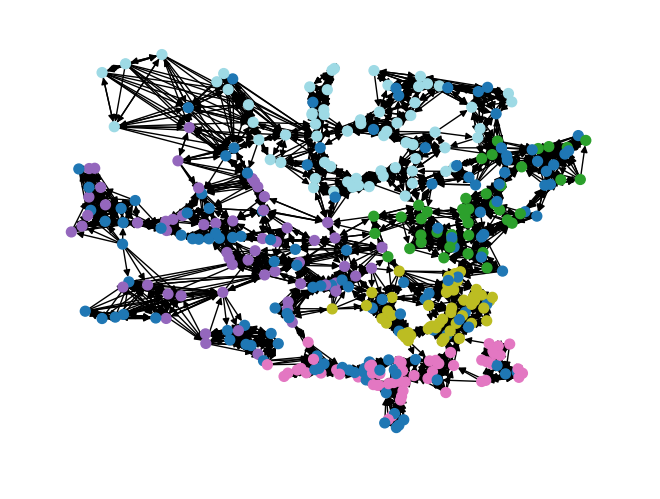

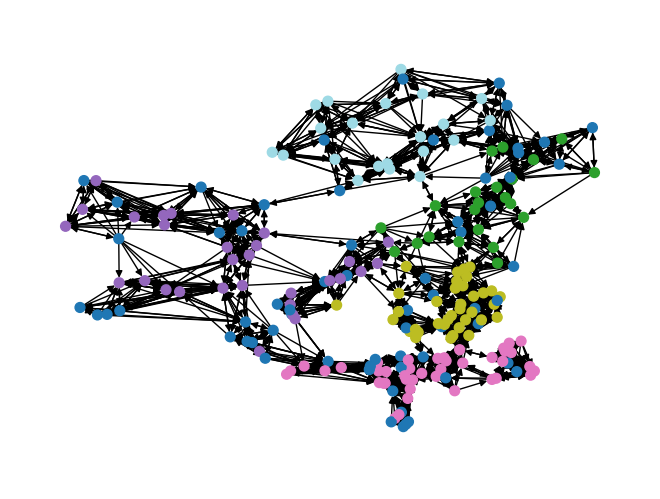

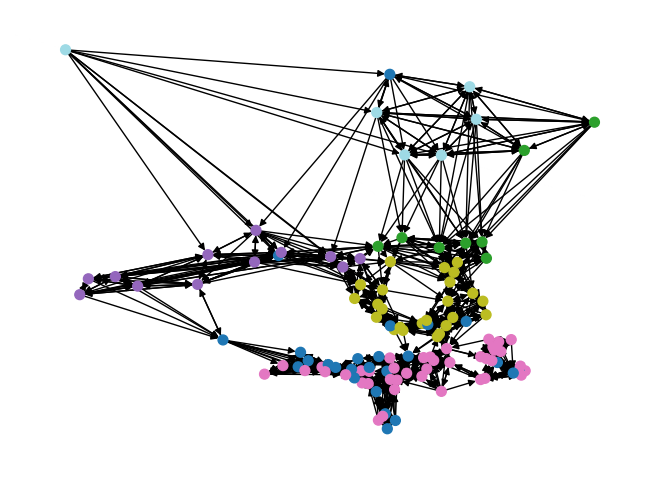

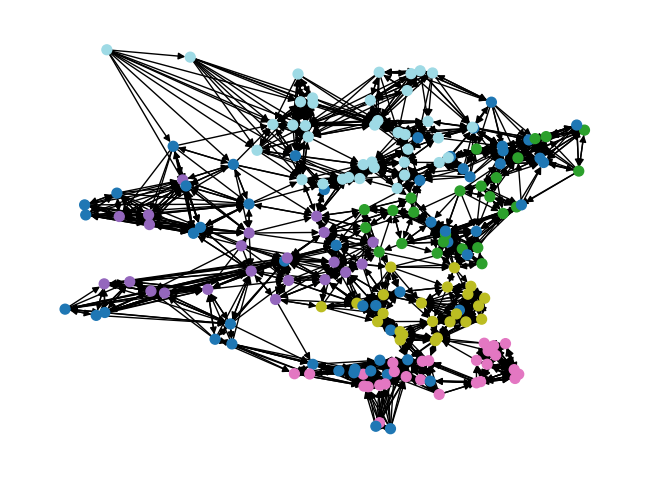

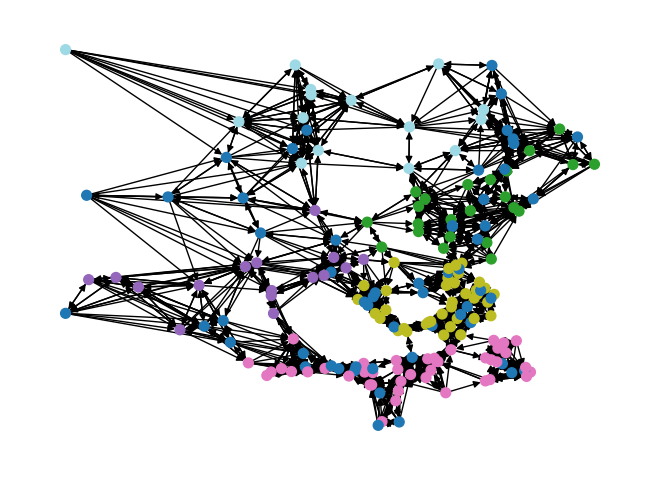

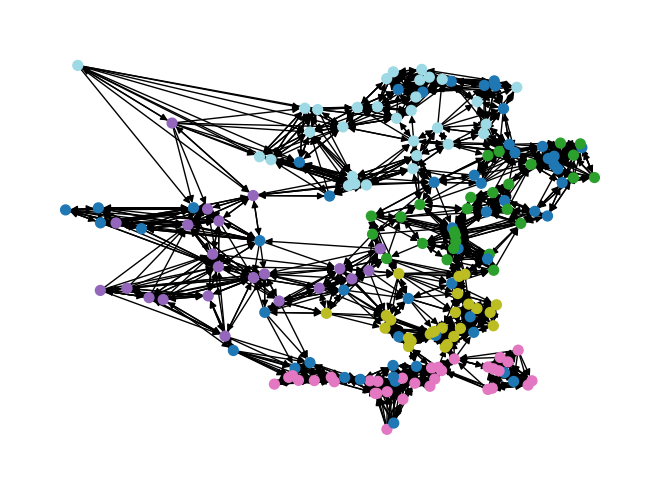

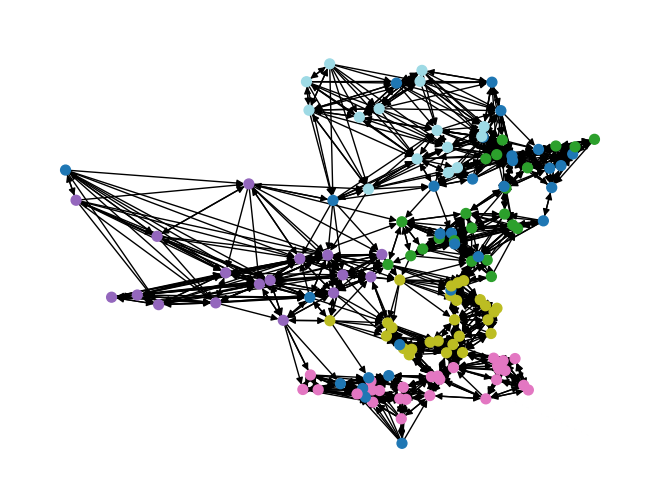

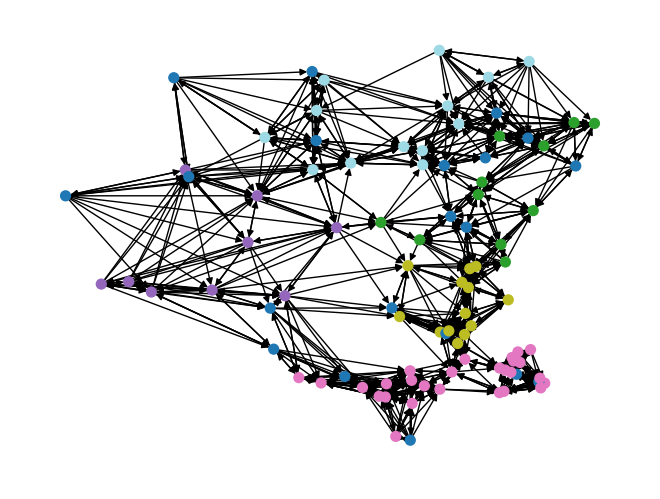

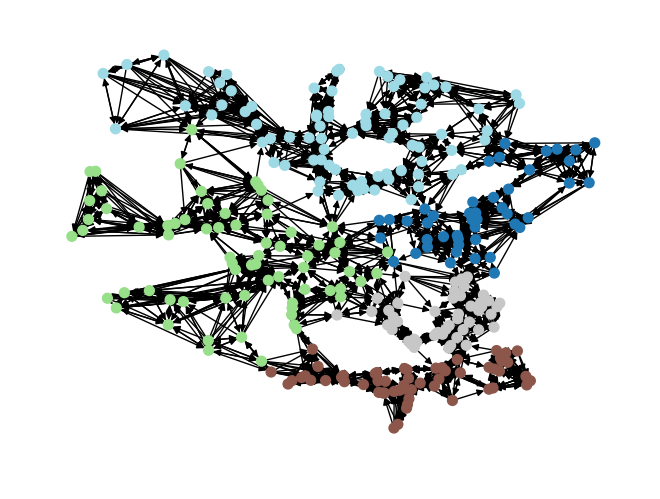

In [24]:
for res in results:
    G_local = results[res]["graph"]
    pos = {n: (G_local.nodes[n]["x"], G_local.nodes[n]["y"]) for n in G_local.nodes()}
    nx.draw(G_local, pos=pos, with_labels=False, node_color=[node_to_cluster.get(n, -1) for n in G_local.nodes()], cmap="tab20", node_size=50)
    plt.show()


In [61]:
res['k']

3